# Signal Investigation

It's finally time! The subsample is now quality controlled, mass-complete, binned into environment quartiles, binned by redshift and stellar mass, and binned into passive/active star formation!

## Finding signal

With quality-controlled, mass-complete subsamples, the search for environmental signals proceeds in a controlled hierarchy. Within each redshift bin and stellar mass bin, measure as a function of environment:

1. Passive fraction.

2. Median $D4000_n$.

3. $H\delta$ strength.

4. OII emission fractions.

Additionally, stellar class and morphological data can be used to find:

1. Fraction of elliptical vs spirals across environment quartiles.

2. What fraction of ellipticals are still spectrally star-forming (at fixed mass)?

3. What fraction of spirals are already passive?

    * Fraction of passive spirals as a function of density.

4. Count spectral classes in each density quartile


At fixed mass and fixed redshift, does increasing density correlate with older stellar populations or higher passive fractions?

In [48]:
import pandas as pd
from pathlib import Path
import numpy as np
from collections import defaultdict
import pickle
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import mode
import matplotlib as mlp
from matplotlib.colors import TwoSlopeNorm
import os
import sys
sys.path.insert(0, "../")
import timescape_functions as tf

# Load analysis sample
analysis_sample = pd.read_csv('analysis_sample.csv')

# Reload z_bin and mass_bin as intervals
analysis_sample = tf.load_bin_intervals(analysis_sample, 0.2, 0.01)
# Merge spiral galaxies
analysis_sample["shape"] = analysis_sample["shape"].replace({
    "spiralclock": "spiral",
    "spiralanticlock": "spiral",
    "edgeon": "spiral"
})

# Load D4000n original data for valley_x value
oii_vals, oii_err_vals, hd_vals, hd_err_vals, d4000n_vals, d4000n_err_vals = tf.load_data('../pickle_folder/line_data.pkl')

p0 = [1000, 1.2, 0.08, 5000, 1.8, 0.006]
_, valley_x = tf.plot_best_fit(d4000n_vals, 0.05, 99.9, p0=p0, bins=300)

In [49]:
def create_contour_plots(analysis_sample, env_type, measured_param):
    """
    Parameters:
    -----------
    env_type -> "5NN" (5NN quartiles), "density" (num density quartiles), "overlap" (agreement between other metrics)

    measured_param -> "sf_type", "D4000n", "hd", "oii
    """
    fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
    axes = axes.flatten()

    #------------------------------------
    #
    # Handle different environment values
    #
    #------------------------------------

    if env_type == "5NN":
        envs = ["Cluster-Like", "Intermediate 1", "Intermediate 2", "Void-Like"]
        env_word = "5NN Distance (Mpc)"
        image_split = "5NN"

    elif env_type == "density":
        envs = ['Void-Like', 'Intermediate 2', 'Intermediate 1', 'Cluster-Like']
        env_word = "Num Density ($Num/Mpc^3$)"
        image_split = "density"

    elif env_type == "overlap":
        envs = ["Cluster-Like", "Intermediate 1", "Intermediate 2", "Void-Like"]
        env_word = "Overlapping Quartile Agreement"
        image_split = "overlap"

    #----------------------------------------------------
    #
    # Handle grid creation for different parameter values
    #
    #----------------------------------------------------

    if measured_param == "sf_type":
        lambda_apply = "Passive"
        colorbar_label = "Passive Fraction" 
        image_name = f"../Images/{measured_param}/pass_f_contour_{image_split}.png"
        plt_title = rf"Passive Fraction by {env_word}"

        grid = (
        analysis_sample
        .groupby(["z_bin", "mass_bin", env_type], observed=True)[measured_param]
        .apply(lambda x: (x==lambda_apply).mean())
        .reset_index(name="f")
    )

    elif measured_param == "D4000n":
        colorbar_label = r"Median $D4000_n$"
        image_name = f"../Images/{measured_param}/d4000n_contour_{image_split}.png"
        plt_title = fr"Median $D4000_n$ contour plot by {env_word}"
        grid = (
            analysis_sample
            .groupby(["z_bin", "mass_bin", env_type], observed=True)[measured_param]
            .median()
            .reset_index(name="f")
        )
        all_vals = grid['f'].values
        finite_vals = all_vals[~np.isnan(all_vals)]
        vmin = finite_vals.min()
        vmax = finite_vals.max()
        vcenter = valley_x
        norm = TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)

    elif measured_param == "hd":
        colorbar_label = r"Median $W_0[H\delta]$"
        image_name = f"../Images/{measured_param}/hd_contour_{image_split}.png"
        plt_title = fr"Median $W_0[H\delta]$ contour plot by {env_word}"
        grid = (
            analysis_sample
            .groupby(["z_bin", "mass_bin", env_type], observed=True)[measured_param]
            .median()
            .reset_index(name="f")
        )
    
    elif measured_param == "oii":
        colorbar_label = r"Median $W_0[OII]$"
        image_name = f"../Images/{measured_param}/oii_contour_{image_split}.png"
        plt_title = fr"Median $W_0[OII]$ contour plot by {env_word}"
        grid = (
            analysis_sample
            .groupby(["z_bin", "mass_bin", env_type], observed=True)[measured_param]
            .median()
            .reset_index(name="f")
        )
    
    #--------------------------------------------------
    #
    # Handle plotting for each env_type/parameter combo
    #
    #--------------------------------------------------

    for ax, env in zip(axes, envs):
        sub = grid[grid[env_type]==env].copy()
        if env == "Unknown":
            continue
        sub["z_center"] = sub["z_bin"].apply(lambda x: x.mid)
        sub["mass_center"] = sub["mass_bin"].apply(lambda x: x.mid)

        pivot = sub.pivot(
            index = "mass_center",
            columns = "z_center",
            values = "f"
        )

        Z = pivot.values
        Z_masked = np.ma.masked_invalid(Z)

        if measured_param == "sf_type":
            cf = ax.contourf(
                pivot.columns,
                pivot.index,
                Z_masked,
                levels=20
            )

        elif measured_param == "D4000n":
            cf = ax.contourf(
                pivot.columns,
                pivot.index,
                Z_masked,
                levels=20,
                norm=norm,
                cmap="seismic"
            )

        elif measured_param == "hd":
            cf = ax.contourf(
                pivot.columns,
                pivot.index,
                Z_masked,
                levels=20,
                cmap="inferno"
            )

        elif measured_param == "oii":
            cf = ax.contourf(
                pivot.columns,
                pivot.index,
                Z_masked,
                levels=20,
                cmap="berlin"
            )

        ax.set_xlabel("Redshift")
        ax.set_ylabel(r"$\log(M/M_\odot)$")
        ax.set_title(env)

    plt.colorbar(cf, ax=axes, label=colorbar_label)
    fig.suptitle(plt_title)
    os.makedirs(f"../Images/{measured_param}", exist_ok=True)
    plt.savefig(image_name)
    plt.show()

    return grid

def create_difference_map(grid, env_type, measured_param):
    """
    Parameters:
    -----------
    env_type -> "5NN" (5NN quartiles), "density" (num density quartiles)

    measured_param -> "sf_type", "D4000n", "hd", "oii
    """
    if env_type == "5NN":
        env_word = "5NN Distance (Mpc)"
        image_split = "5NN"

    elif env_type == "density":
        env_word = "Num Density ($Num/Mpc^3$)"
        image_split = "density"

    elif env_type == "overlap":
        env_word = "Overlapping Quartile Agreement"
        image_split = "overlap"

    cluster = grid[grid[env_type]=="Cluster-Like"]
    void    = grid[grid[env_type]=="Void-Like"]

    merged_env = cluster.merge(
        void,
        on=["z_bin", "mass_bin"],
        suffixes=("_cluster", "_void")
    )

    merged_env["delta"] = (
        merged_env["f_cluster"] - merged_env["f_void"]
    )

    if measured_param == "sf_type":
        colorbar_label = r"$\Delta f$"
        print_word = "Delta frac"
        plt_title = rf"$\Delta f$ by {env_word}"
        image_name = f"../Images/{measured_param}/passive_f_difference_{image_split}.png"

    elif measured_param == "D4000n":
        colorbar_label = r"$\Delta D4000_n$"
        print_word = "Delta D4000n"
        plt_title = rf"$\Delta D4000_n$ by {env_word}"
        image_name = f"../Images/{measured_param}/d4000n_difference_{image_split}.png"

    elif measured_param == "hd":
        colorbar_label = r"$\Delta W_0[H\delta]$"
        print_word = "Delta Hd"
        plt_title = rf"$\Delta W_0[H\delta]$ by {env_word}"
        image_name = f"../Images/{measured_param}/hd_difference_{image_split}.png"

    elif measured_param == "oii":
        colorbar_label = r"$\Delta W_0[O\text{ }II]$"
        print_word = "Delta OII"
        plt_title = rf"$\Delta W_0[OII]$ by {env_word}"
        image_name = f"../Images/{measured_param}/oii_difference_{image_split}.png"


    print(f"{print_word} mean: {merged_env['delta'].mean():.3f} \pm {merged_env['delta'].std():.3f}")
    print(f"{print_word} min: {merged_env['delta'].min():.3f}")
    print(f"{print_word} max: {merged_env['delta'].max():.3f}")

    merged_env = merged_env.copy()
    merged_env["z_center"] = merged_env["z_bin"].apply(lambda x: x.mid)
    merged_env["mass_center"] = merged_env["mass_bin"].apply(lambda x: x.mid)
    pivot = merged_env.pivot(
        index="mass_center",
        columns="z_center",
        values="delta"
    )
    Z = pivot.values

    v = np.nanmax(np.abs(Z))

    norm = TwoSlopeNorm(vmin=-v, vcenter=0, vmax=v)
    plt.contourf(
        pivot.columns,
        pivot.index,
        Z,
        levels=20,
        cmap="RdBu_r",
        norm=norm
    )

    plt.xlabel("Redshift")
    plt.ylabel(r"$\log(M/M_\odot)$")
    plt.title(plt_title)
    plt.colorbar(label=colorbar_label)
    plt.tight_layout()
    os.makedirs(f"../Images/{measured_param}", exist_ok=True)
    plt.savefig(image_name)
    plt.show()

def plot_quartiles_by_redshift_and_mass(analysis_sample, env_type, measured_param):
    """
    Parameters:
    -----------
    env_type -> "5NN" (5NN quartiles), "density" (num density quartiles)

    measured_param -> "sf_type", "D4000n", "hd", "oii
    """
    if env_type == "5NN":
        env_word = "5NN Distance (Mpc)"
        image_split = "5NN"

    elif env_type == "density":
        env_word = "Num Density ($Num/Mpc^3$)"
        image_split = "density"

    elif env_type == "overlap":
        env_word = "Overlapping Quartile Agreement"
        image_split = "overlap"

    z_grouped    = analysis_sample.groupby(["z_bin", env_type], observed=True)
    mass_grouped = analysis_sample.groupby(["mass_bin", env_type], observed=True)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5), sharey=False, sharex=False)

    if measured_param == "sf_type":
        ylabel="Passive Fraction"
        ax1_title = r"Passive fraction evolution over redshift"
        ax2_title = r"Passive fraction evolution across stellar mass"
        image_name = f"../Images/{measured_param}/{measured_param}_z_mass_{image_split}.png"
        z_stats = z_grouped[measured_param].agg(
            N="count",
            f=lambda x: (x=="Passive").mean()
        ).reset_index()
        z_stats["z_center"] = z_stats["z_bin"].apply(lambda x: x.mid)
        z_stats["sigma_f"] = np.sqrt(z_stats["f"] * (1-z_stats["f"]) / z_stats["N"])
        for env in z_stats[env_type].unique():
            if env == "Unknown":
                continue
            sub = z_stats[z_stats[env_type]==env]
            ax1.errorbar(
                sub["z_center"],
                sub["f"],
                yerr=sub["sigma_f"],
                label=f"{env} ({sub['N'].sum()})"
            )
        
        mass_stats = mass_grouped[measured_param].agg(
            N="count",
            f=lambda x: (x=="Passive").mean()
        ).reset_index()
        mass_stats["mass_center"] = mass_stats["mass_bin"].apply(lambda x: x.mid)
        mass_stats["sigma_f"] = np.sqrt(mass_stats["f"] * (1-mass_stats["f"]) / mass_stats["N"])
        for env in mass_stats[env_type].unique():
            if env == "Unknown":
                continue
            sub = mass_stats[mass_stats[env_type]==env]
            ax2.errorbar(
                sub["mass_center"],
                sub["f"],
                yerr=sub["sigma_f"],
                label=f"{env} ({sub['N'].sum()})"
            )
    
    else:
        if measured_param == "D4000n":
            ax1_title = r"Median $D4000_n$ evolution over redshift"
            ax2_title = r"Median $D4000_n$ evolution across stellar mass"
            ylabel = r"Median $D4000_n$"
            image_name = f"../Images/{measured_param}/d4000n_z_mass_{image_split}.png"

        if measured_param == "hd":
            ax1_title = r"Median $W_0[H\delta]$ evolution over redshift"
            ax2_title = r"Median $W_0[H\delta]$ evolution across stellar mass"
            ylabel = r"Median $W_0[H\delta]$"
            image_name = f"../Images/{measured_param}/hd_z_mass_{image_split}.png"

        if measured_param == "oii":
            ax1_title = r"Median $W_0[OII]$ evolution over redshift"
            ax2_title = r"Median $W_0[OII]$ evolution across stellar mass"
            ylabel = r"Median $W_0[OII]$"
            image_name = f"../Images/{measured_param}/oii_z_mass_{image_split}.png"

        z_stats = z_grouped[measured_param].agg(
            N="count",
            median="median",
            std="std"
        ).reset_index()

        z_stats["yerr"] = z_stats["std"] / np.sqrt(z_stats["N"])
        z_stats["z_center"] = z_stats["z_bin"].apply(lambda x: x.mid)
        for env, sub in z_stats.groupby(env_type):
            if env == "Unknown":
                continue
            sub = sub.sort_values("z_center")
            ax1.errorbar(
                sub["z_center"],
                sub["median"],
                yerr=sub["yerr"],
                label=f"{env} ({sub['N'].sum()})"
            )

        mass_stats = mass_grouped[measured_param].agg(
            N="count",
            median="median",
            std="std"
        ).reset_index()

        mass_stats["yerr"] = mass_stats["std"] / np.sqrt(mass_stats["N"])
        mass_stats["mass_center"] = mass_stats["mass_bin"].apply(lambda x: x.mid)
        for env, sub in mass_stats.groupby(env_type):
            if env == "Unknown":
                continue
            sub = sub.sort_values("mass_center")
            ax2.errorbar(
                sub["mass_center"],
                sub["median"],
                yerr=sub["yerr"],
                label=f"{env} ({sub['N'].sum()})"
            )

    if measured_param == "D4000n":
        ax1.axhline(valley_x, linestyle='dashed')
        ax2.axhline(valley_x, linestyle='dashed')

    ax1.set_xlabel("Redshift")
    ax1.set_ylabel(ylabel)
    ax1.set_title(ax1_title)
    ax2.set_title(ax2_title)
    ax2.set_xlabel("$\log(M/M_\odot)$")
    fig.suptitle(f"Evolution quartiles by {env_word}")
    plt.legend()
    plt.tight_layout()
    os.makedirs(f"../Images/{measured_param}/", exist_ok=True)
    plt.savefig(image_name)
    plt.show()

# Compare Passive Fraction Evolution

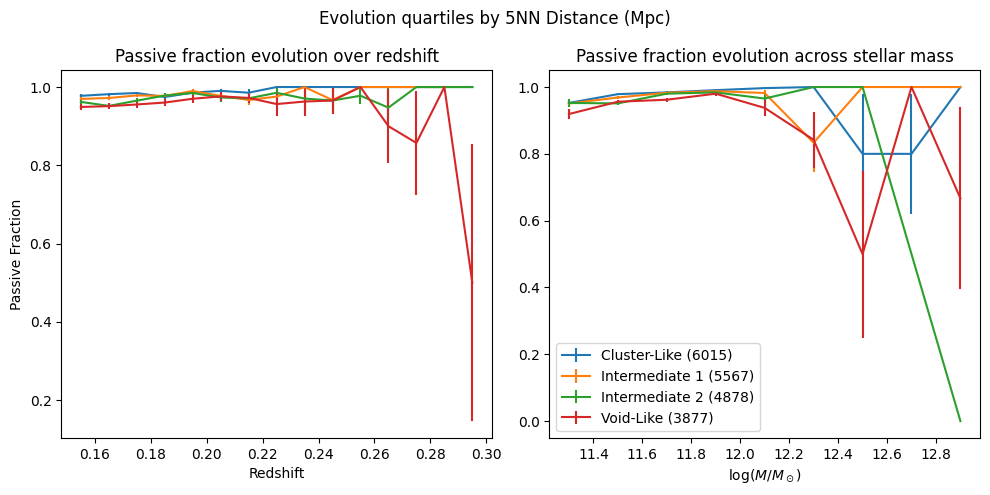

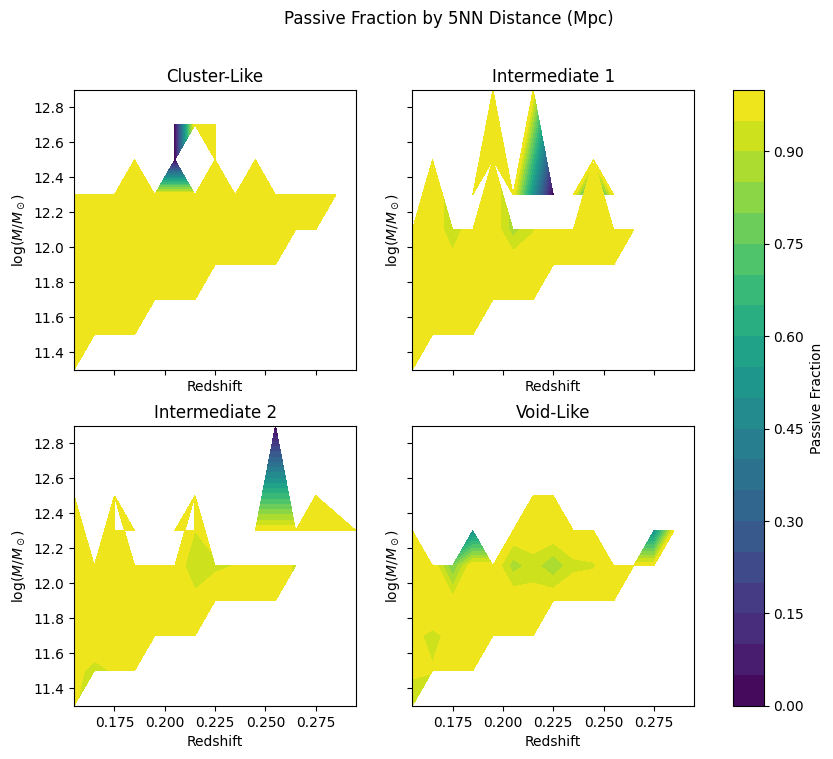

Delta frac mean: 0.052 \pm 0.125
Delta frac min: -0.032
Delta frac max: 0.500


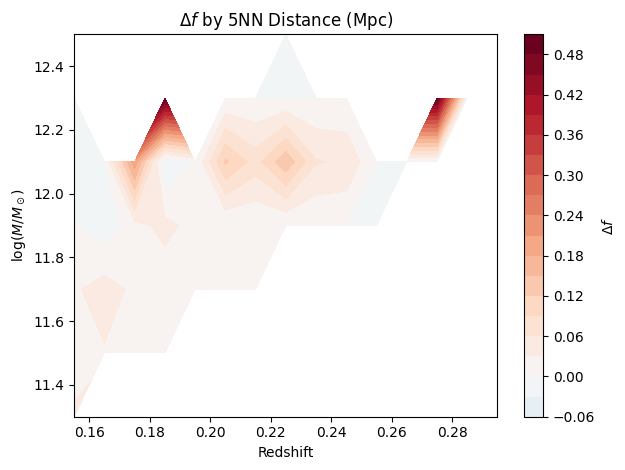

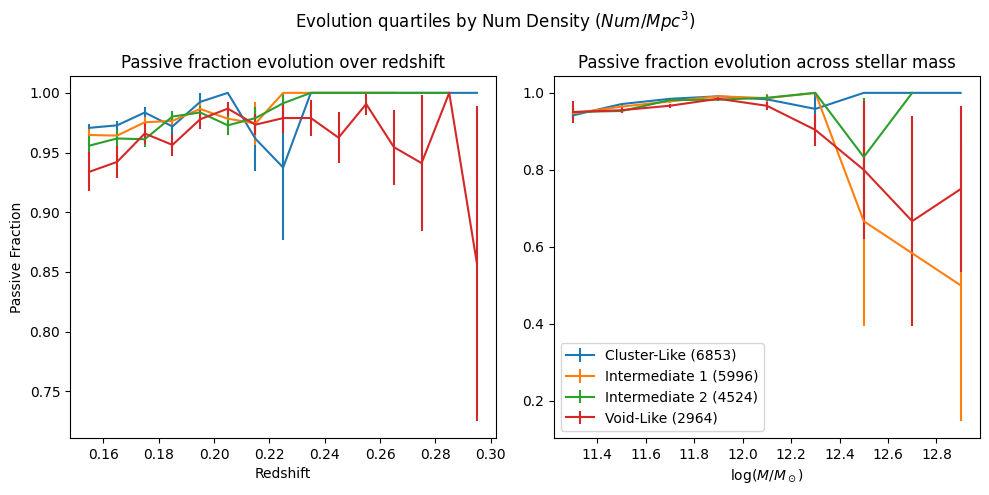

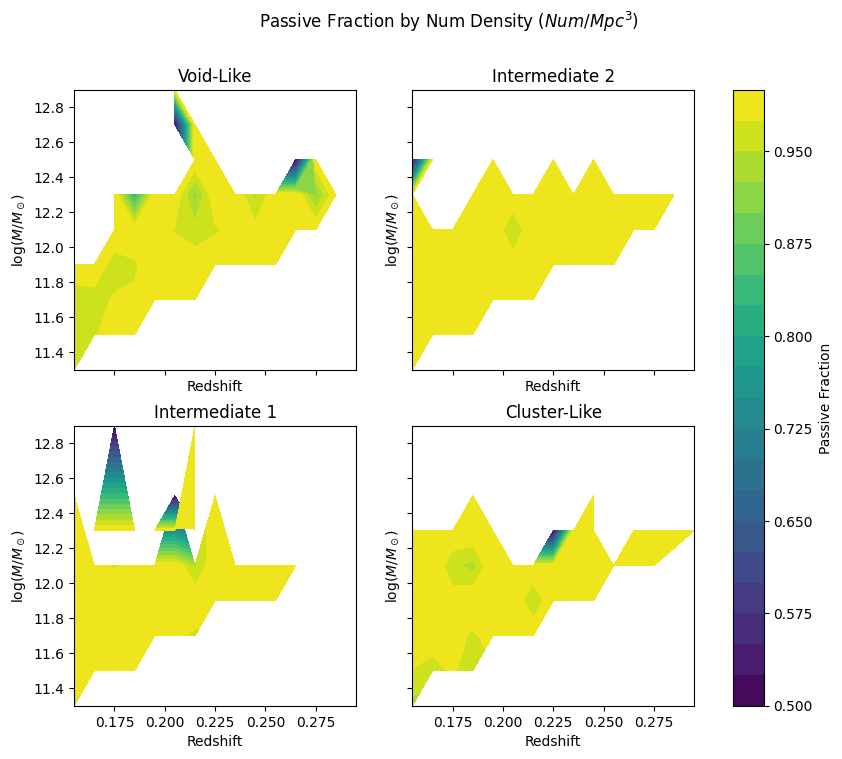

Delta frac mean: 0.019 \pm 0.105
Delta frac min: -0.500
Delta frac max: 0.333


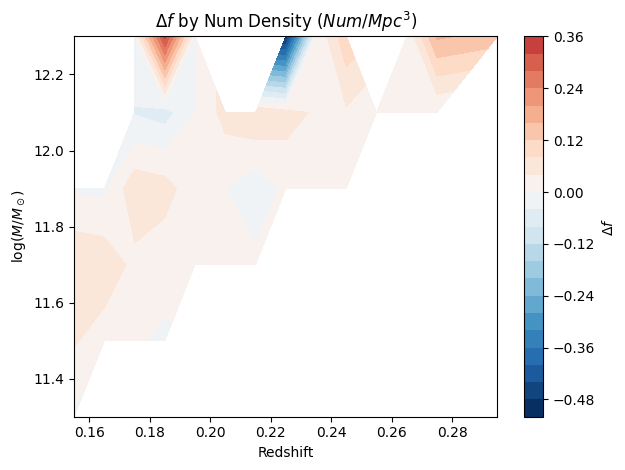

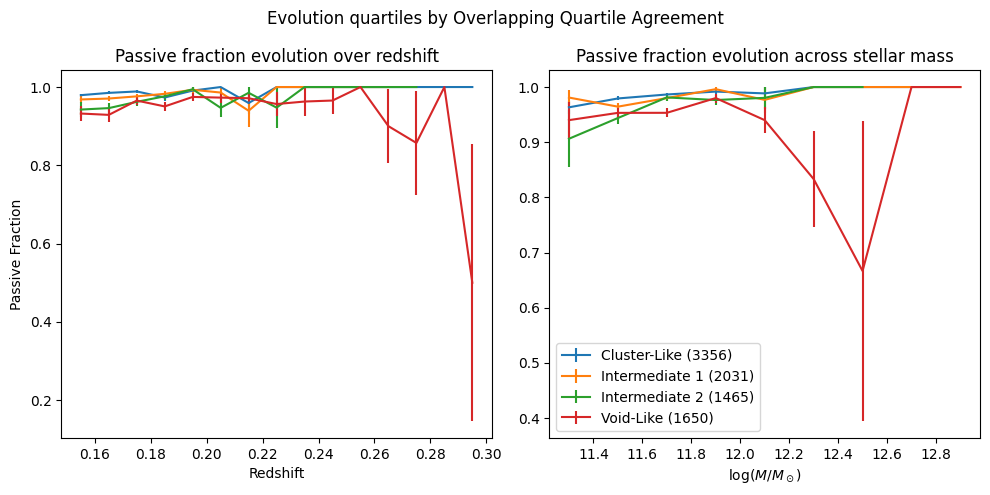

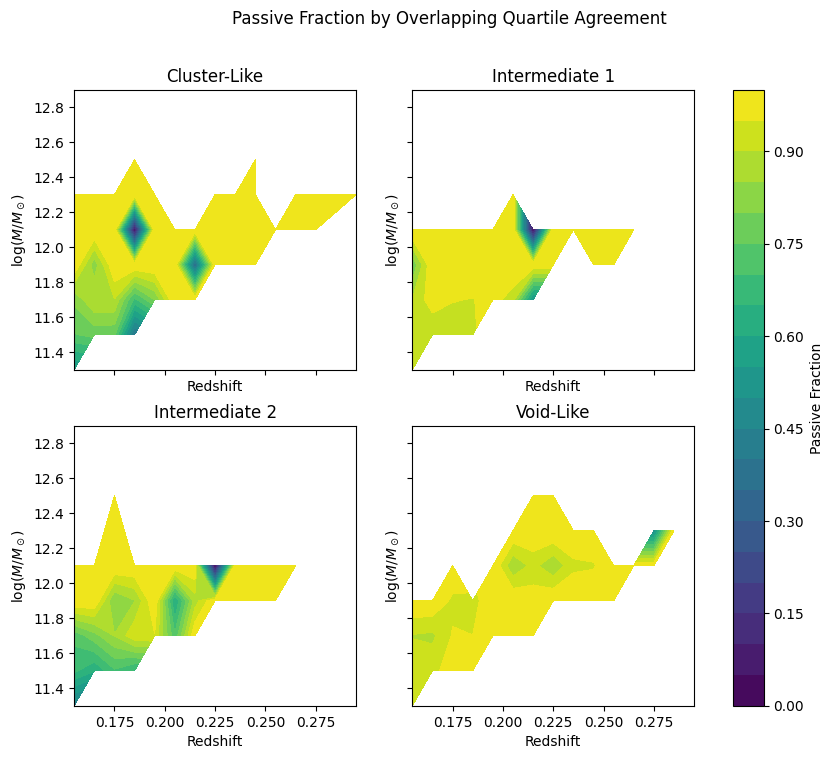

Delta frac mean: 0.066 \pm 0.135
Delta frac min: -0.030
Delta frac max: 0.500


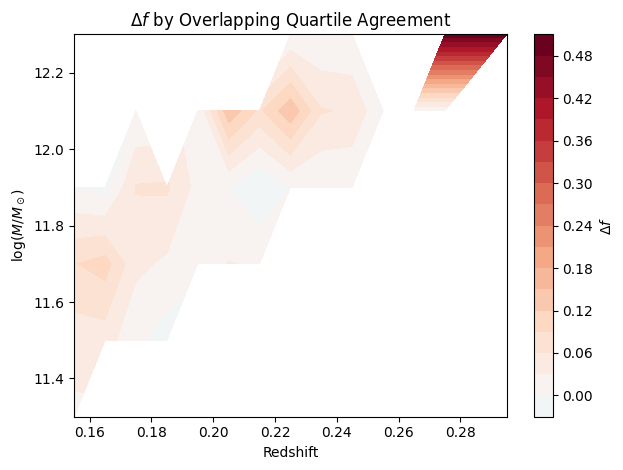

In [50]:
env_list = ["5NN", "density", "overlap"]
for env in env_list:
    plot_quartiles_by_redshift_and_mass(analysis_sample, env, "sf_type")
    grid = create_contour_plots(analysis_sample, env, "sf_type")
    create_difference_map(grid, env, "sf_type")

# Compare median $D4000_n$ evolution

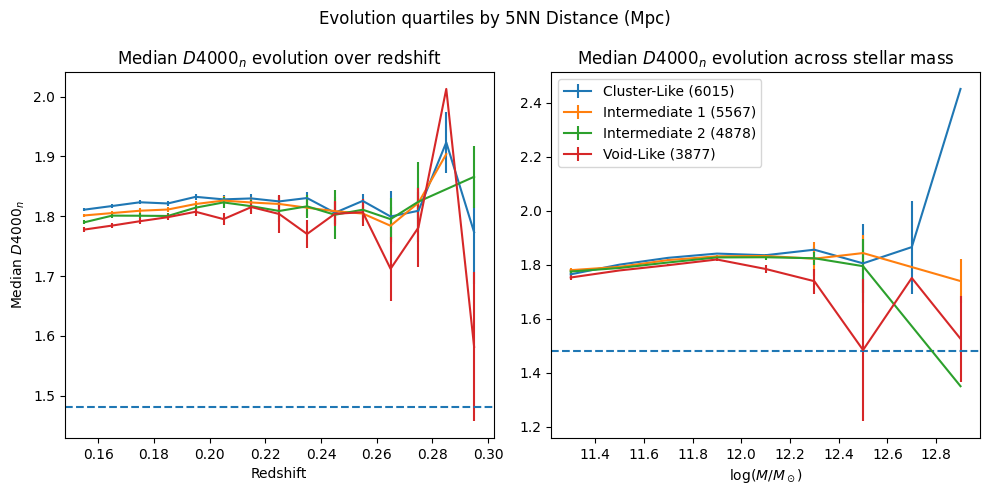

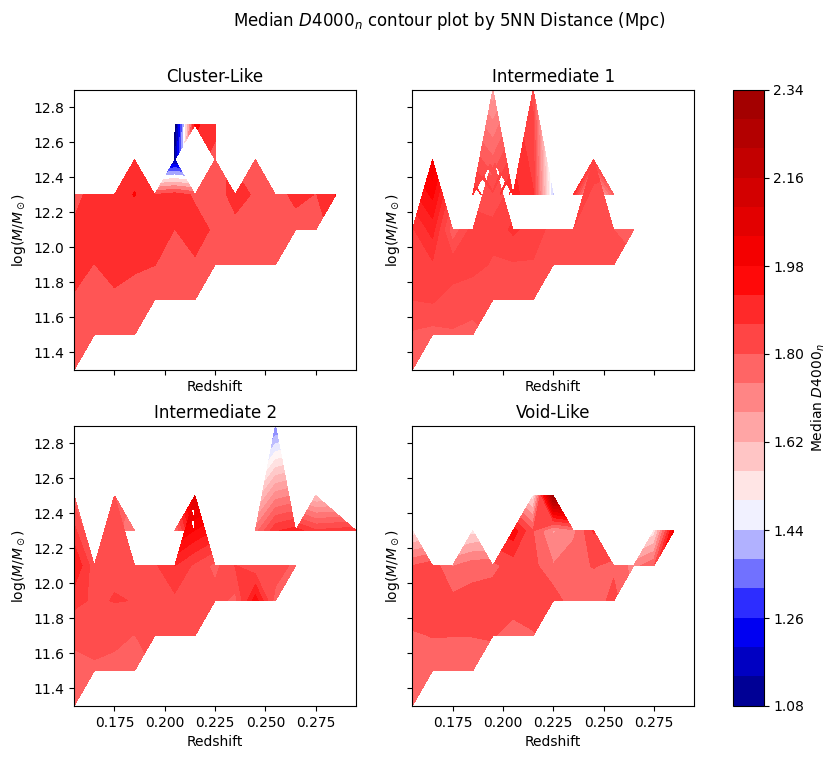

Delta D4000n mean: 0.042 \pm 0.122
Delta D4000n min: -0.525
Delta D4000n max: 0.389


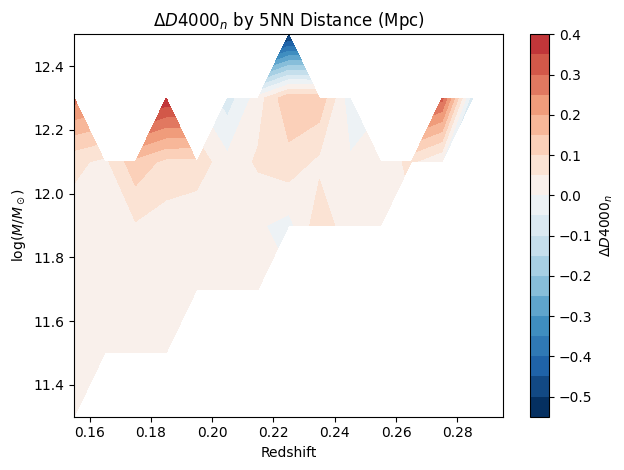

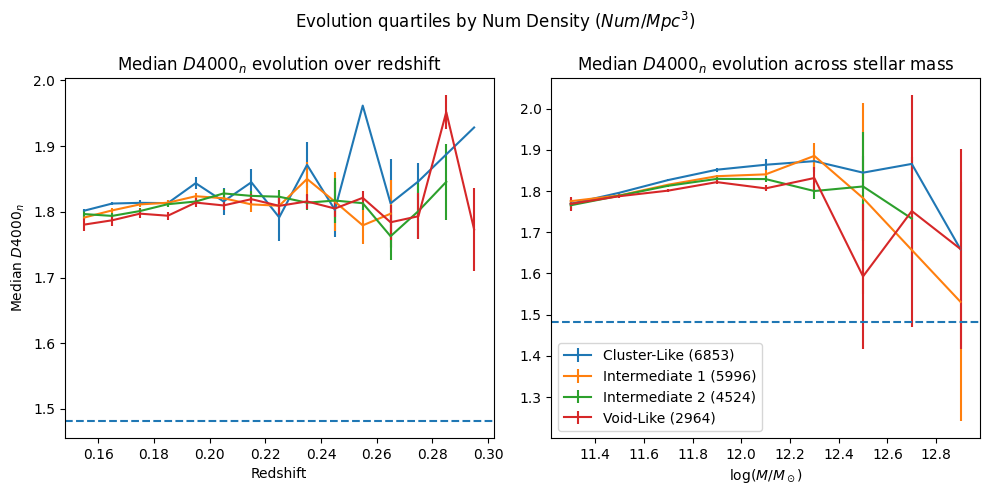

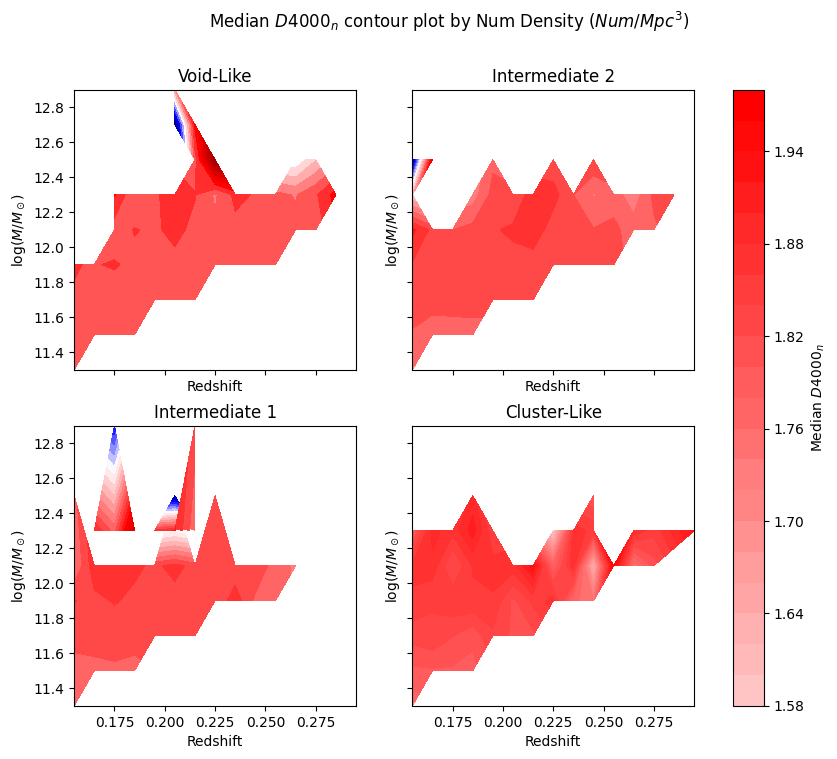

Delta D4000n mean: 0.017 \pm 0.063
Delta D4000n min: -0.177
Delta D4000n max: 0.155


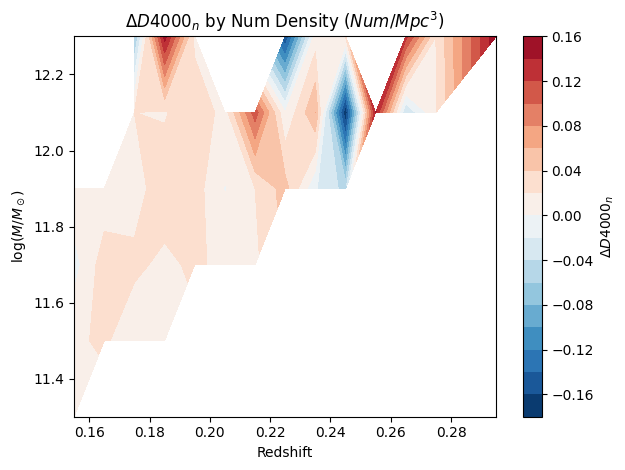

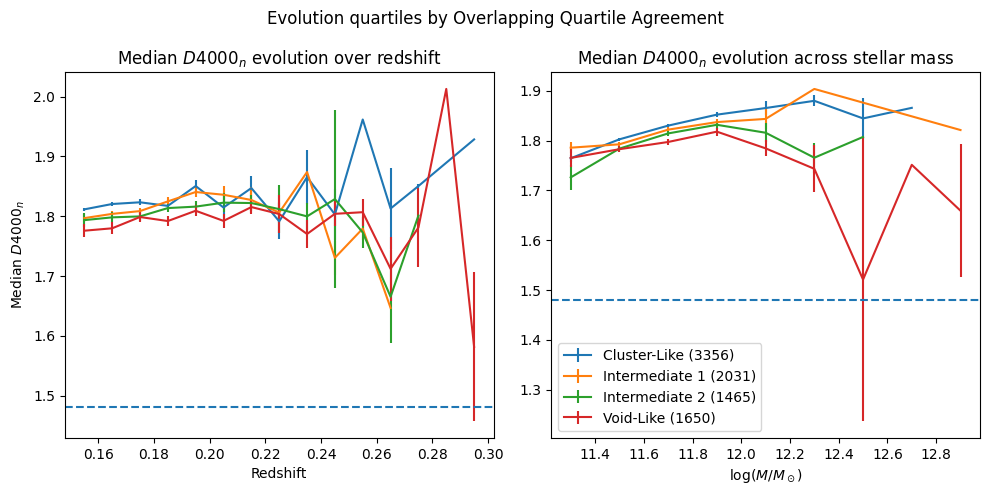

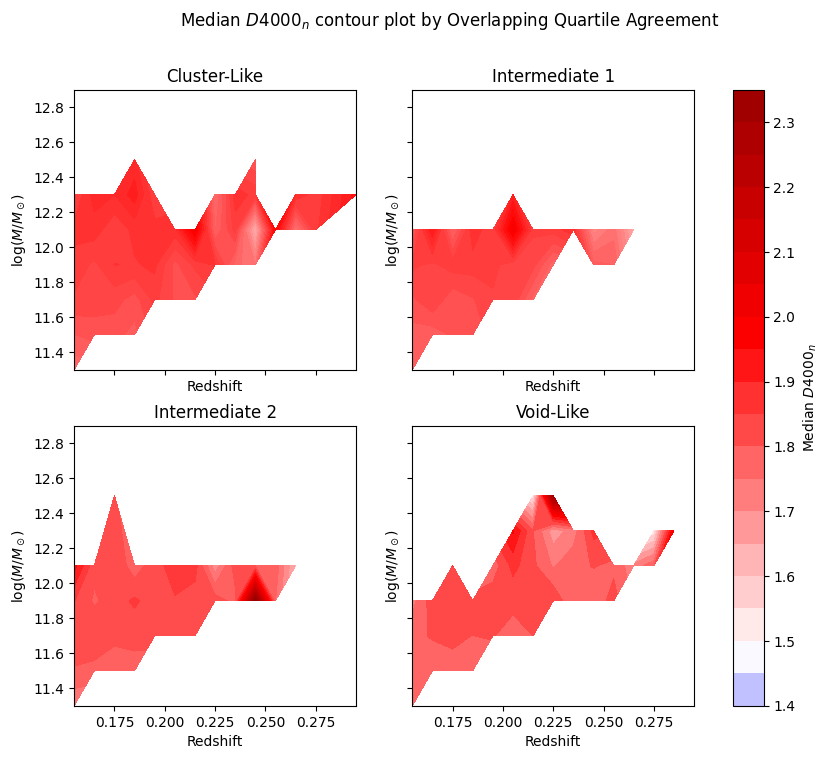

Delta D4000n mean: 0.061 \pm 0.104
Delta D4000n min: -0.170
Delta D4000n max: 0.376


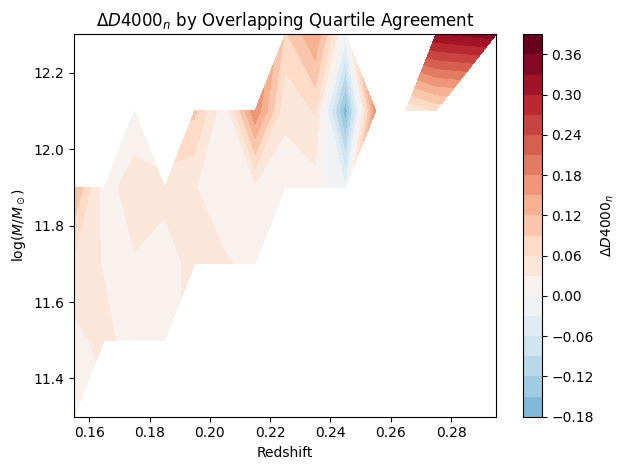

In [51]:
env_list = ["5NN", "density", "overlap"]
for env in env_list:
    plot_quartiles_by_redshift_and_mass(analysis_sample, env, "D4000n")
    grid = create_contour_plots(analysis_sample, env, "D4000n")
    create_difference_map(grid, env, "D4000n")

# Compare median $W_0[H\delta]$ strength evolution

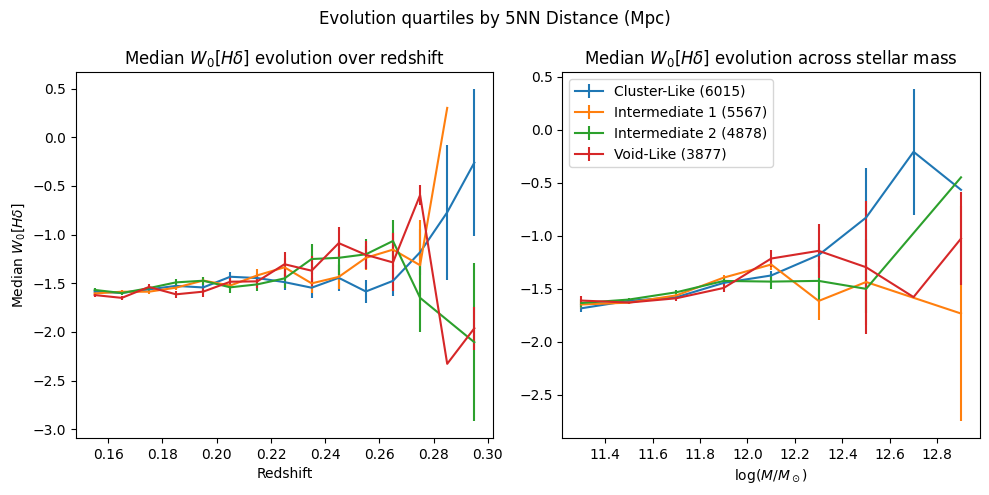

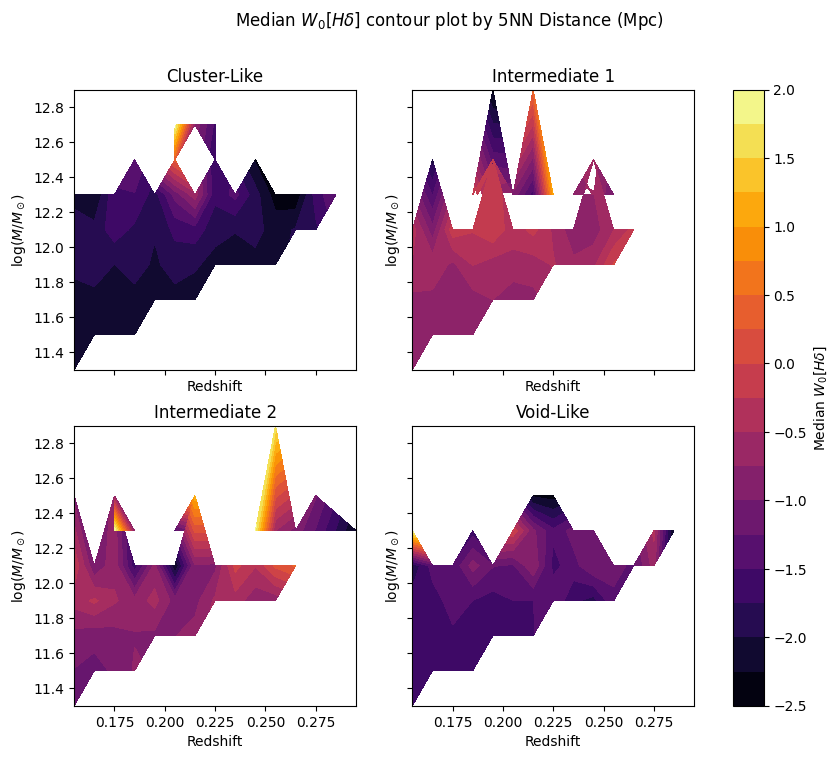

Delta Hd mean: -0.005 \pm 0.713
Delta Hd min: -3.533
Delta Hd max: 1.701


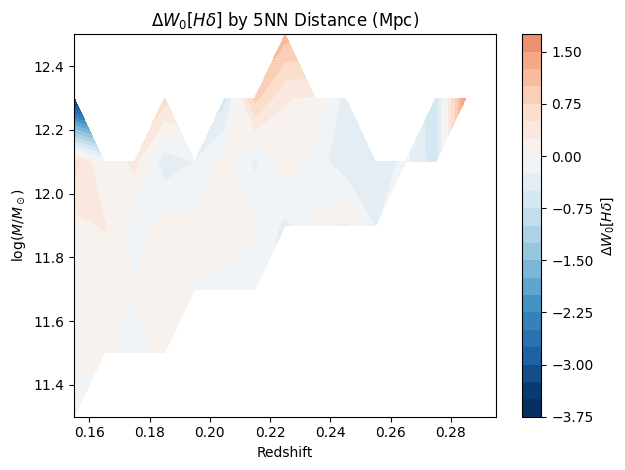

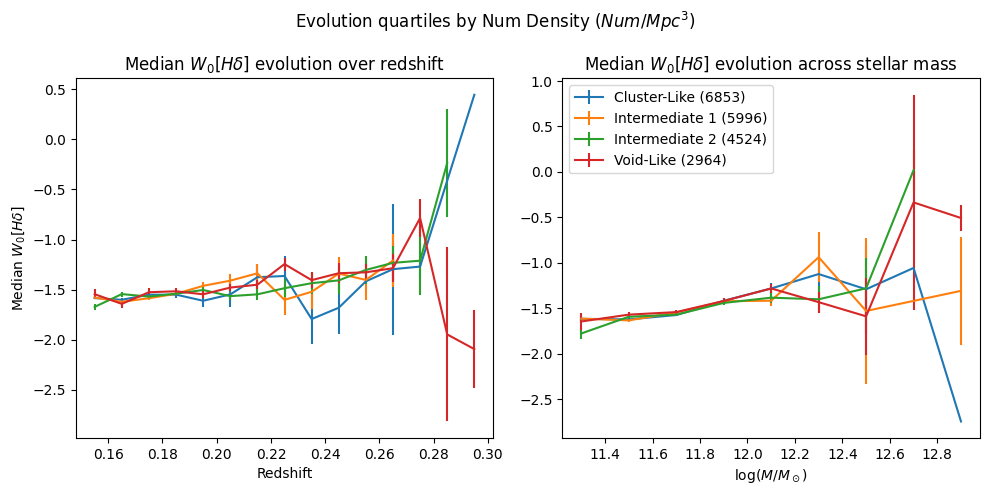

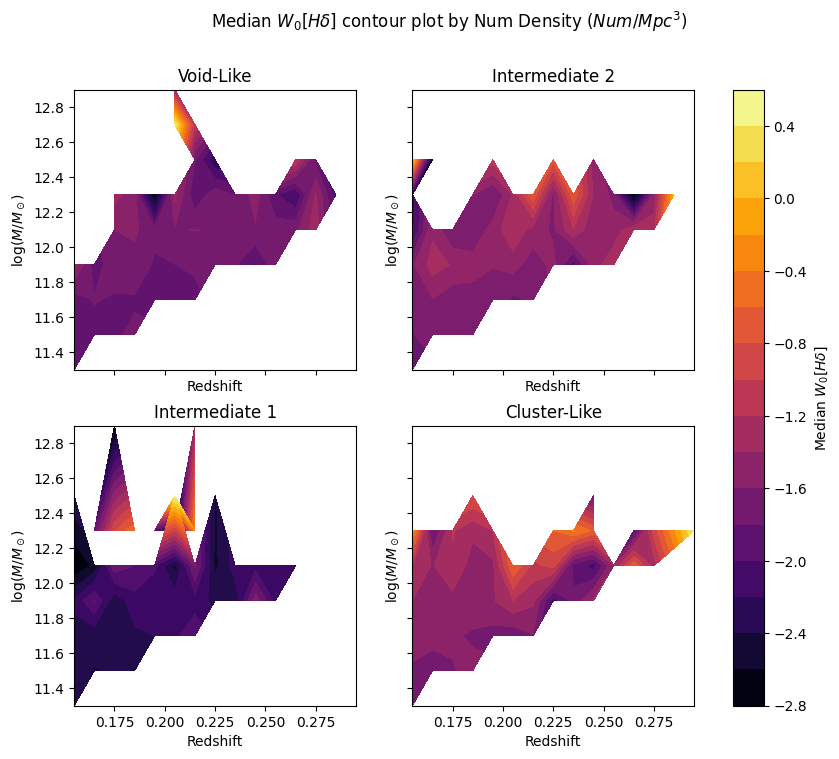

Delta Hd mean: 0.095 \pm 0.623
Delta Hd min: -0.848
Delta Hd max: 2.539


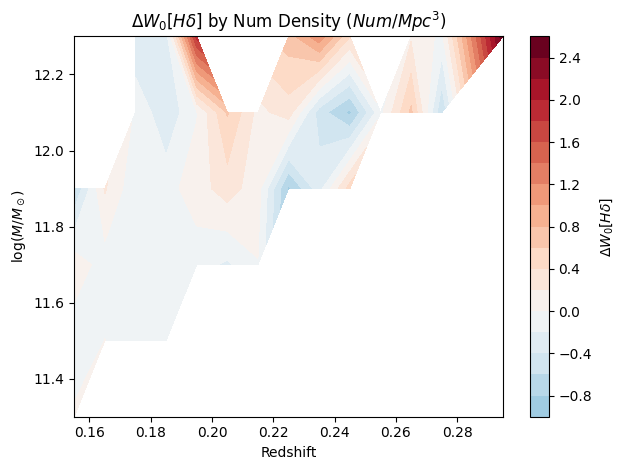

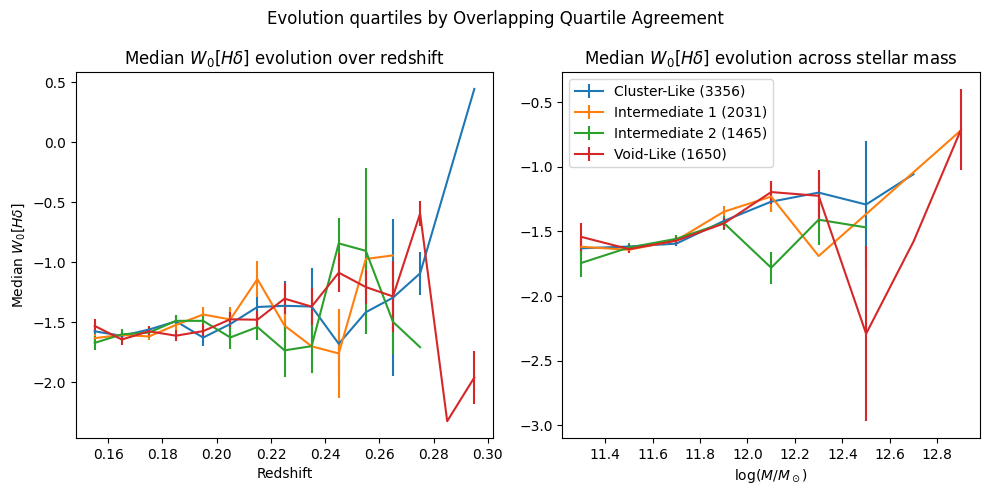

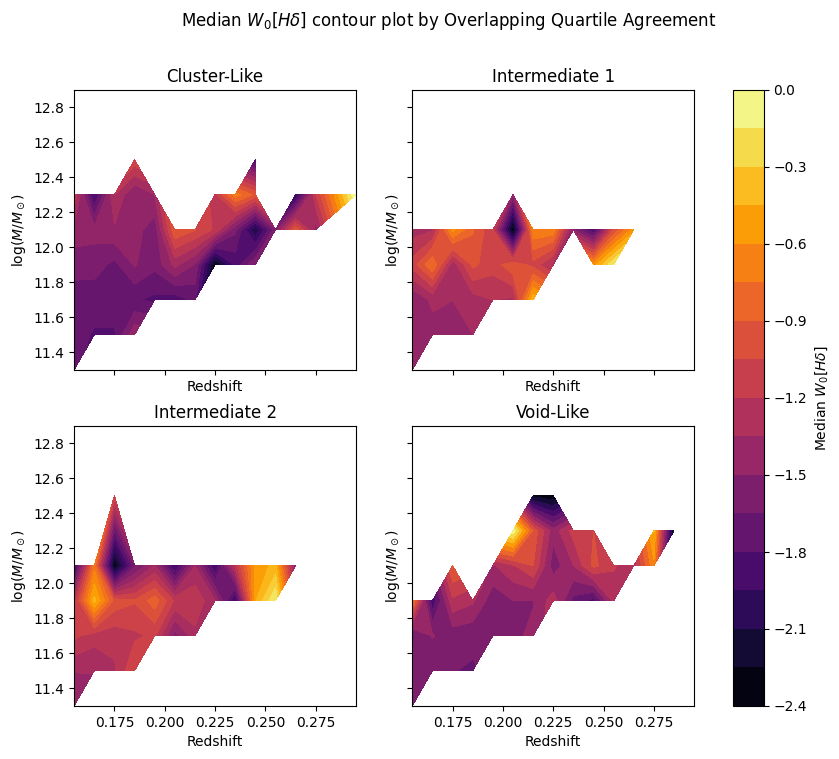

Delta Hd mean: 0.075 \pm 0.583
Delta Hd min: -1.078
Delta Hd max: 2.407


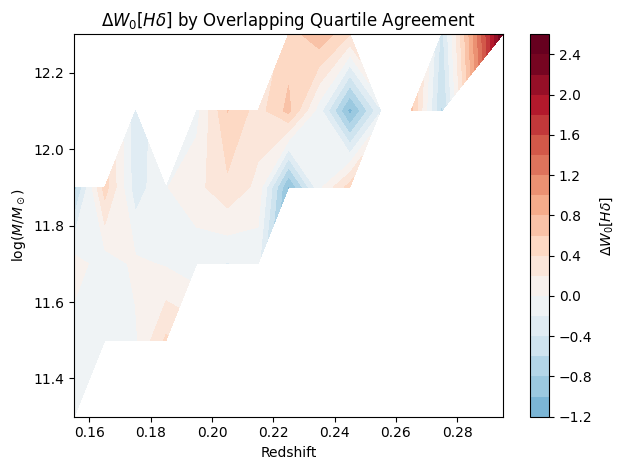

In [52]:
env_list = ["5NN", "density", "overlap"]
for env in env_list:
    plot_quartiles_by_redshift_and_mass(analysis_sample, env, "hd")
    grid = create_contour_plots(analysis_sample, env, "hd")
    create_difference_map(grid, env, "hd")

# Compare median $W_0[OII]$ evolution

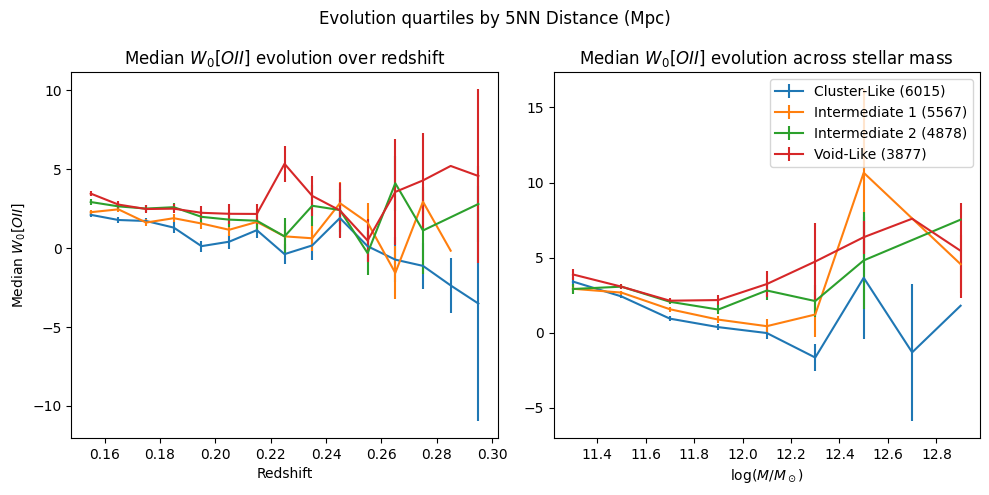

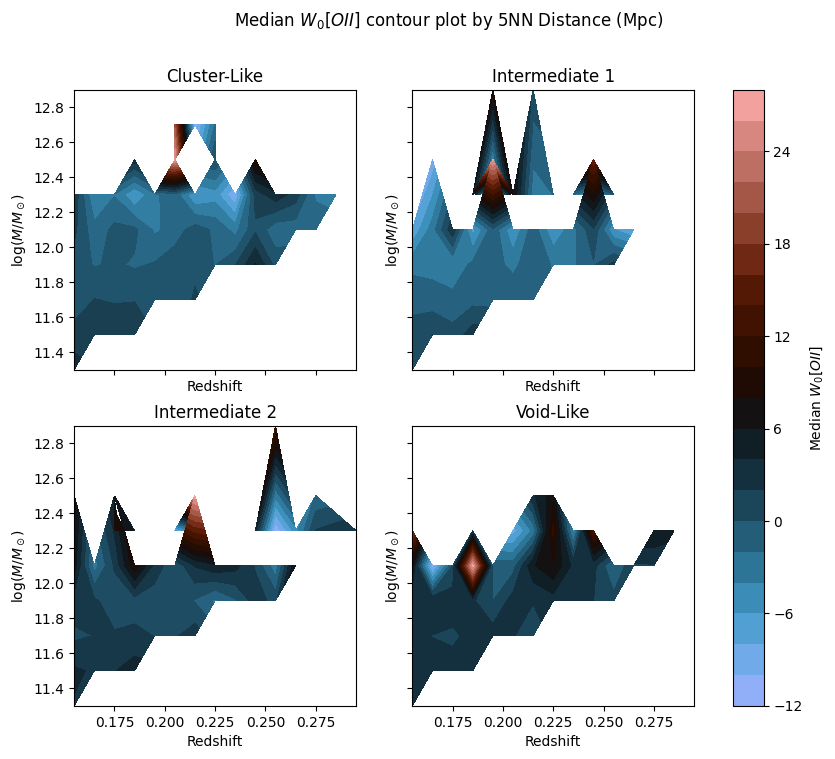

Delta OII mean: -3.074 \pm 5.761
Delta OII min: -26.587
Delta OII max: 10.109


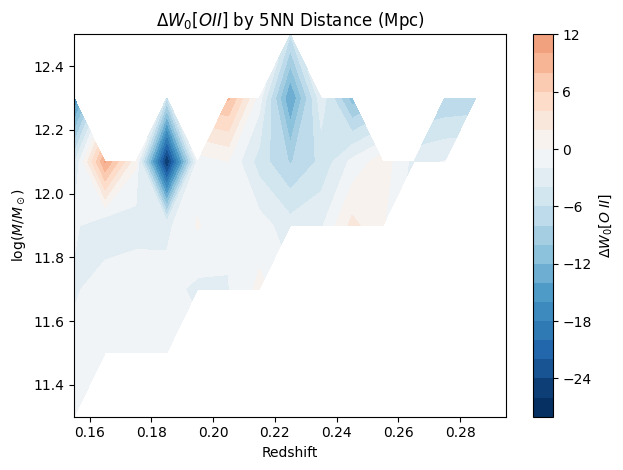

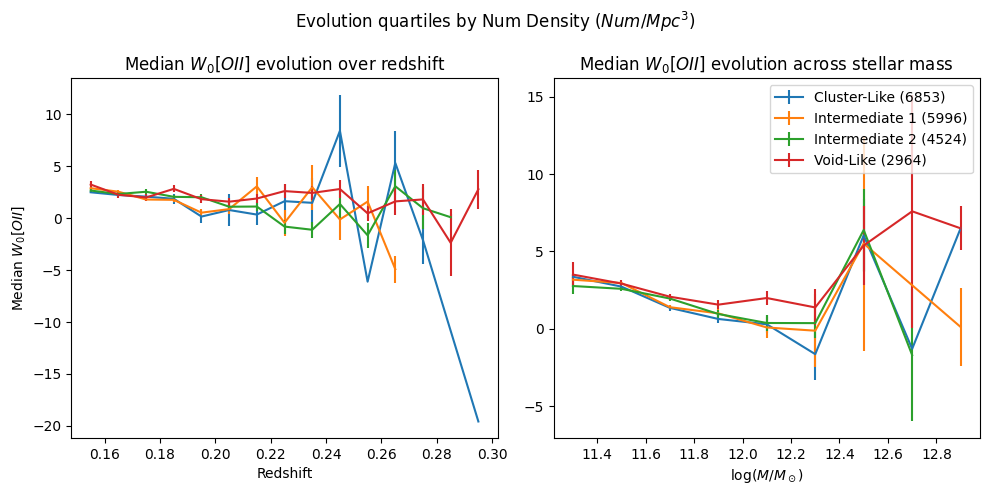

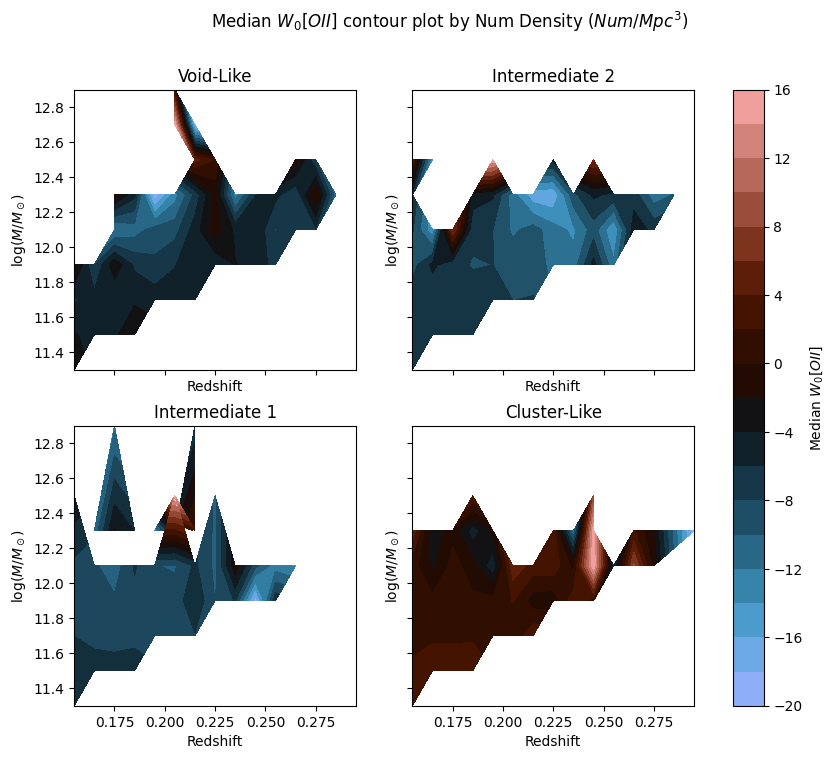

Delta OII mean: -0.840 \pm 5.741
Delta OII min: -22.373
Delta OII max: 13.973


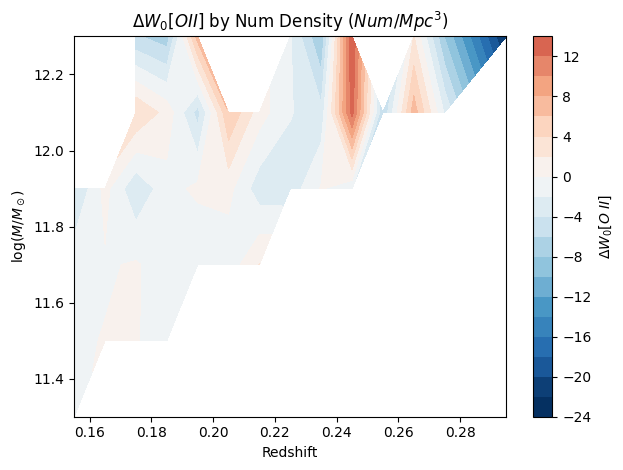

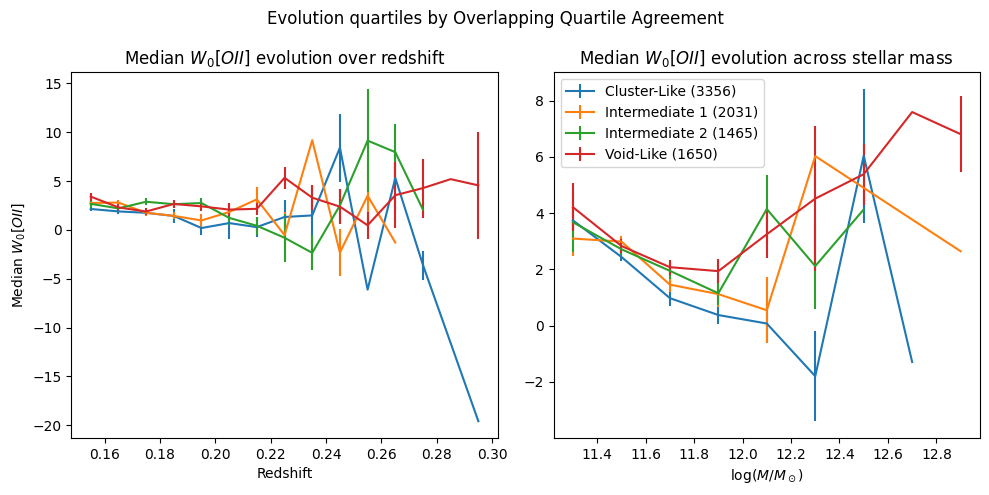

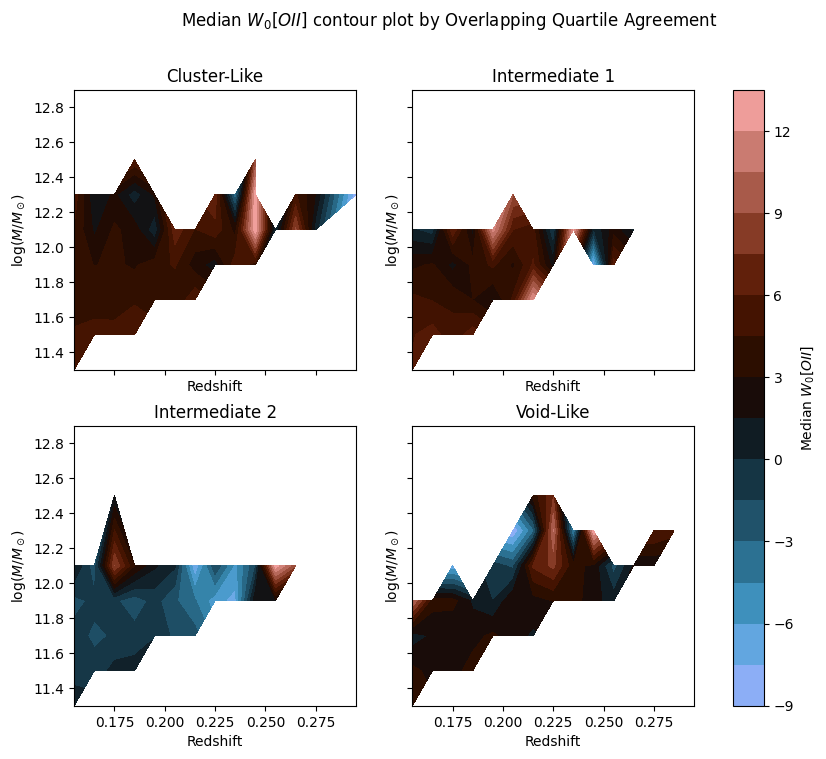

Delta OII mean: -2.027 \pm 5.873
Delta OII min: -24.145
Delta OII max: 13.008


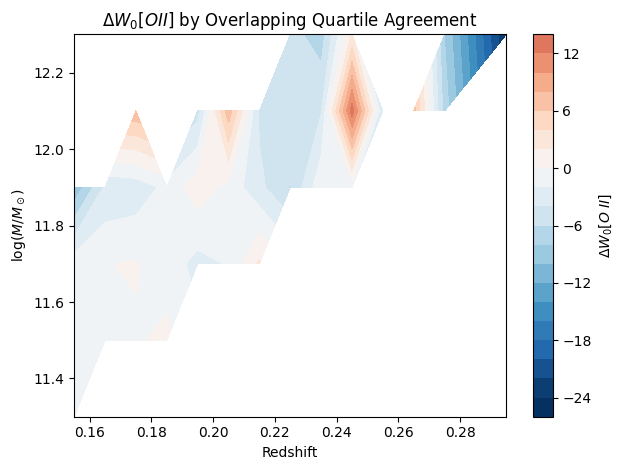

In [53]:
env_list = ["5NN", "density", "overlap"]
for env in env_list:
    plot_quartiles_by_redshift_and_mass(analysis_sample, env, "oii")
    grid = create_contour_plots(analysis_sample, env, "oii")
    create_difference_map(grid, env, "oii")

# Investigate how environment effects distributions of galaxies by class and shape

In [150]:
def plot_population_vs_environment(analysis_sample, env_type, population_type, ax=None):
    """
    Parameters
    ----------
    env_type -> "5NN", "density", "overlap"
    population_type -> "class", "shape"
    """
    col = population_type

    if env_type == "5NN":
        env_word = "5NN Distance (Mpc)"
        image_split = "5NN"

    elif env_type == "density":
        env_word = "Num Density ($Num/Mpc^3$)"
        image_split = "density"

    elif env_type == "overlap":
        env_word = "Overlapping Agreement"
        image_split = "overlap"

    if population_type == "class":
        title = "Galaxy Class Counts vs Environment"
        image_name = f"../Images/populations/class_vs_env_{image_split}.png"

    elif population_type == "shape":
        title = "Galaxy Morphology Counts vs Environment"
        image_name = f"../Images/populations/shape_vs_env_{image_split}.png"

    df = analysis_sample.copy()
    df = df[df[env_type] != "Unknown"]

    if population_type == "shape":
        # Skip unknown types
        df = df[df["shape"] != "dontknow"]

    quartile_order = [
        "Cluster-Like",
        "Intermediate 1",
        "Intermediate 2",
        "Void-Like"
    ]

    df[env_type] = pd.Categorical(df[env_type], categories=quartile_order, ordered=True)

    counts = (
        df.groupby([env_type, col], observed=True)
        .size()
        .unstack(fill_value=0)
        .reindex(quartile_order)
    )

    N = counts.sum(axis=1)

    percent = counts.div(N, axis=0) * 100
    frac = counts.div(N, axis=0)
    sigma = np.sqrt(frac * (1 - frac) / N.values[:, None]) * 100

    print(f"N:\n",N)
    print(f"percent:\n",percent)
    print(f"sigma:\n",sigma)
    print()

    x = np.arange(len(quartile_order))

    if ax is None:
        fig, ax = plt.subplots(figsize=(7,5))

    for population in percent.columns:
        ax.errorbar(
            x,
            percent[population],
            yerr=sigma[population],
            label=population
        )

    ax.set_xticks(x, quartile_order, rotation=30)
    ax.set_ylabel("Galaxy Type (%)")

    title = env_word
    ax.set_title(title)

    if ax.get_legend() is None:
        ax.legend()
    #plt.tight_layout()

    #os.makedirs("../Images/populations/", exist_ok=True)
    #plt.savefig(image_name)

    return ax

N:
 5NN
Cluster-Like      95
Intermediate 1    51
Intermediate 2    54
Void-Like         50
dtype: int64
percent:
 shape           elliptical     spiral
5NN                                  
Cluster-Like     94.736842   5.263158
Intermediate 1   86.274510  13.725490
Intermediate 2   96.296296   3.703704
Void-Like        90.000000  10.000000
sigma:
 shape           elliptical    spiral
5NN                                 
Cluster-Like      2.290978  2.290978
Intermediate 1    4.818591  4.818591
Intermediate 2    2.569958  2.569958
Void-Like         4.242641  4.242641

N:
 density
Cluster-Like      85
Intermediate 1    34
Intermediate 2    46
Void-Like         85
dtype: int64
percent:
 shape           elliptical    spiral
density                             
Cluster-Like     91.764706  8.235294
Intermediate 1   91.176471  8.823529
Intermediate 2   91.304348  8.695652
Void-Like        94.117647  5.882353
sigma:
 shape           elliptical    spiral
density                             
Clu

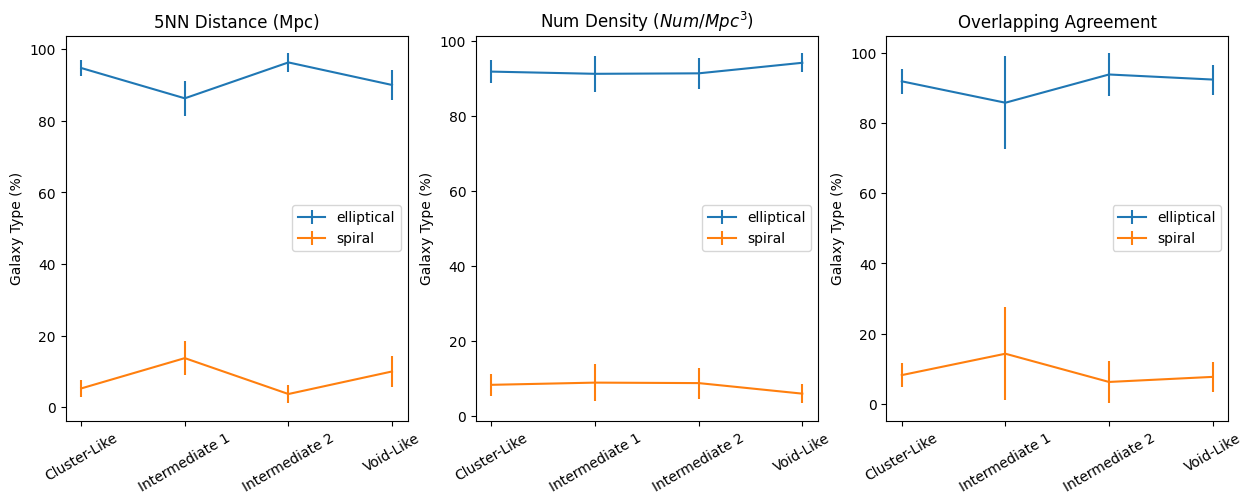

In [151]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

env_list = ["5NN", "density", "overlap"]
for i, env in enumerate(env_list):
    plot_population_vs_environment(analysis_sample, env, "shape", ax=axes[i])

plt.show()

N:
 5NN
Cluster-Like      6015
Intermediate 1    5567
Intermediate 2    4878
Void-Like         3877
dtype: int64
percent:
 class               e(b)       e(c)          k
5NN                                           
Cluster-Like    0.033250  86.882793  13.083957
Intermediate 1  0.035926  87.228310  12.735764
Intermediate 2  0.123001  90.077901   9.799098
Void-Like       0.000000  90.147021   9.852979
sigma:
 class               e(b)      e(c)         k
5NN                                         
Cluster-Like    0.023508  0.435281  0.434812
Intermediate 1  0.025399  0.447345  0.446807
Intermediate 2  0.050184  0.428046  0.425674
Void-Like       0.000000  0.478643  0.478643

N:
 density
Cluster-Like      6853
Intermediate 1    5996
Intermediate 2    4524
Void-Like         2964
dtype: int64
percent:
 class               e(b)       e(c)          k
density                                       
Cluster-Like    0.014592  89.274770  10.710638
Intermediate 1  0.050033  88.458973  11.490994
I

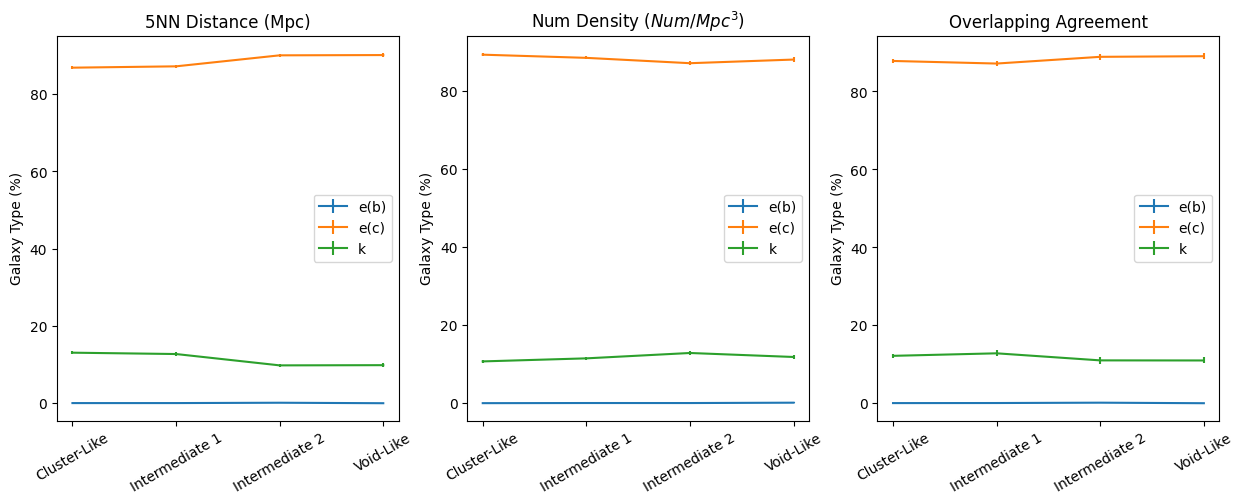

In [152]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, env in enumerate(env_list):
    plot_population_vs_environment(analysis_sample, env, "class", ax=axes[i])

plt.show()